<a href="https://colab.research.google.com/github/maureen-zhang/qiskit-subset-sum/blob/main/SUBSET_SUM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What needs
to be written in this document:

**Clear all the veraible and notation , so the code is easto read. **
** each functon deserve one block **


Q whats the largest valiue needed for the sum
https://arxiv.org/pdf/2410.01775


  Circuits to buit(functions to call):
* H-gate
* adder

---

* documentation for setup/notation for vanilla Grover search, including words about size of data access oracle - Silas
* efficient adder subroutine - Maureen
* marker which marks target state t - Maureen
* diffuser - Silas





# Subset-Sum Problem

**Input**: a finite list of positive integers $\{m_0, m_1, \dots, m_{n-1}\}$ and a positive integer $t$.

**Output**: a subset $I \subseteq \{0, 1, \dots, n-1\}$ such that $\sum_{i \in I} m_i = t$, or decides, with high probability, that no such subset exists.

# Solution using Grover's search algorithm

We will solve this problem using Grover's quantum search algorithm. We will implement:

- A quantum register of $n$ qubits representing bitstrings $x_0 x_1 \dots x_n$ of length $n$, which correspond to subsets $I \subseteq \{0, 1, \dots, n-1\}$.

- An ancilla register of $d$ qubits, where $d$ is a positive integer which is sufficiently large that we can represent all possible sums $\sum_{i \in I} x_i$ as binary bitstrings.

We will implement the marker oracle using adder circuits constructed by Akos Nagy.

In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import ZGate

import matplotlib.pyplot as plt

import numpy as np

## Initializing global variables

In [2]:
# M = given list of positive integers
M = np.array([1,3,5,8])

# n = number of positive integers provided
n = len(M)

# target_sum = the target sum we want to achieve by summing a subset of the integers in M
target_sum = 6

# We need to determine the number of bits needed to represent the maximum possible sum of subsets of M
max_sum = sum(M)
bits_needed = int(max_sum).bit_length()

We now initialize the quantum, ancilla, and carry registers.

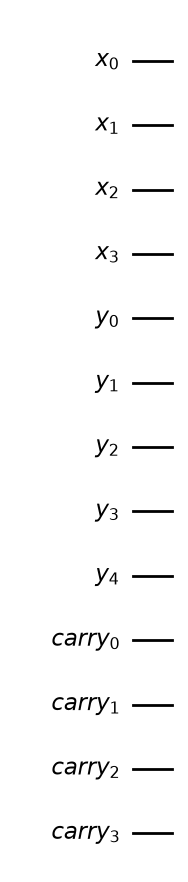

In [3]:
quantum_register = QuantumRegister(size=n, name='x')
ancilla_register = AncillaRegister(size=bits_needed, name='y')
carry_register = AncillaRegister(size=bits_needed-1, name='carry')

qc = QuantumCircuit(quantum_register, ancilla_register, carry_register)
qc.draw(output="mpl")

# Adder Circuit (credit Akos)

The frist step of coverting the subset sum problem in to a grover search problem is to encode it into a function $F$.

We are given a list of positive integers $\{m_0, m_1 , \dots, m_{n-1} \}$

Let $F: \mathbb{F}_2^n \rightarrow \mathbb{Z}$ be defined as

\begin{equation}
    F(x_0, x_1 , \dots, x_n) = m_0 x_0 + m_1 x_1 \dots + m_{n-1} x_{n-1}
\end{equation}

Our goal is the solve the equation

\begin{equation}
    F(x_0, x_1, \dots x_{n-1}) = t,
\end{equation}

using Grover's algorithm.

Special thanks to Akos for making his adder circuit available to the open-source quantum computing community.

**Adder Circuit:**
github.com/akos-nagy/quantum_shifter



In [4]:
def controlled_measurement_free_quantum_shifter(k, d):
    if not (isinstance(k, int) and isinstance(d, int) and d > 0):
        raise TypeError(f"k and d have to be integers and d has to be positive")
        return 0

    k %= 1 << d

    qcontrol = QuantumRegister(1, "control")
    qregx = QuantumRegister(d, "x")
    quantum_shifter_circuit = QuantumCircuit(qcontrol, qregx, name=f"{d}-bit controlled {k}-shifter")

    if d == 1 and k == 1:
        quantum_shifter_circuit.cx(qcontrol[0], qregx[0])
        return quantum_shifter_circuit

    qcarry = AncillaRegister(d - 1, "carry")
    quantum_shifter_circuit.add_register(qcarry)

    if k == 0:
        return quantum_shifter_circuit

    least_significant_bit = (-k&k).bit_length() - 1 # at least 0

    if least_significant_bit > 0:
        quantum_shifter_circuit.compose(controlled_measurement_free_quantum_shifter(k >> least_significant_bit, d - least_significant_bit), qubits=qcontrol[:] + qregx[least_significant_bit:] + qcarry[least_significant_bit:], inplace=True)
        return quantum_shifter_circuit

    compute_carry_gate = compute_carry().to_gate()
    uncompute_carry_gate = compute_carry_gate.inverse()
    uncompute_carry_gate.label = f"uncompute carry"

    if d == 2:
        if k == 1:
            quantum_shifter_circuit.compose(compute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)
            quantum_shifter_circuit.cx(qcarry[0], qregx[1])
            quantum_shifter_circuit.compose(uncompute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)
            quantum_shifter_circuit.cx(qcontrol[0], qregx[0])
        if k == 3:
            quantum_shifter_circuit.cx(qcontrol[0], qregx[0])
            quantum_shifter_circuit.compose(compute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)
            quantum_shifter_circuit.cx(qcarry[0], qregx[1])
            quantum_shifter_circuit.compose(uncompute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)
        return quantum_shifter_circuit

    # k is now odd

    k_bits = (k >> np.arange(d))%2

    if k_bits[0] == 1:
        quantum_shifter_circuit.cx(qcontrol[0], qregx[0])   
    quantum_shifter_circuit.compose(compute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)
    
    for idx in range(d - 2):
        if k_bits[idx] != k_bits[idx + 1]:
            quantum_shifter_circuit.cx(qcontrol[0], qcarry[idx])
        if k_bits[idx + 1] == 1:
            quantum_shifter_circuit.cx(qcarry[idx], qregx[idx + 1])
        quantum_shifter_circuit.compose(compute_carry_gate, qubits=[qcarry[idx], qregx[idx + 1], qcarry[idx + 1]], inplace=True)

    if k_bits[- 2] != k_bits[- 1]:
        quantum_shifter_circuit.cx(qcontrol[0], qregx[- 1])
    quantum_shifter_circuit.cx(qcarry[- 1], qregx[- 1])

    for idx in range(d - 3, - 1, - 1):
        quantum_shifter_circuit.compose(uncompute_carry_gate, qubits=[qcarry[idx], qregx[idx + 1], qcarry[idx + 1]], inplace=True)
        if k_bits[idx + 1] == 0:
            quantum_shifter_circuit.cx(qcarry[idx], qregx[idx + 1])
        if k_bits[idx] != k_bits[idx + 1]:
            quantum_shifter_circuit.cx(qcontrol[0], qcarry[idx])

    quantum_shifter_circuit.compose(uncompute_carry_gate, qubits=[qcontrol[0], qregx[0], qcarry[0]], inplace=True)

    if k_bits[0] == 0:
        quantum_shifter_circuit.cx(qregx[0], qregx[1])
        quantum_shifter_circuit.x(qregx[0])

    return quantum_shifter_circuit


def compute_carry():
    qcontrol, qtarget = QuantumRegister(2, "control"), AncillaRegister(1, "target")

    compute_carry_gate = QuantumCircuit(qcontrol, qtarget, name=f"compute carry")

    compute_carry_gate.h(qtarget[0])
    compute_carry_gate.t(qtarget[0])

    compute_carry_gate.cx(qcontrol[0], qtarget[0])
    compute_carry_gate.cx(qcontrol[1], qtarget[0])
    compute_carry_gate.cx(qtarget[0], qcontrol[1])
    compute_carry_gate.cx(qtarget[0], qcontrol[0])

    compute_carry_gate.tdg(qcontrol)
    compute_carry_gate.t(qtarget[0])

    compute_carry_gate.cx(qtarget[0], qcontrol[0])
    compute_carry_gate.cx(qtarget[0], qcontrol[1])

    compute_carry_gate.h(qtarget[0])

    return compute_carry_gate

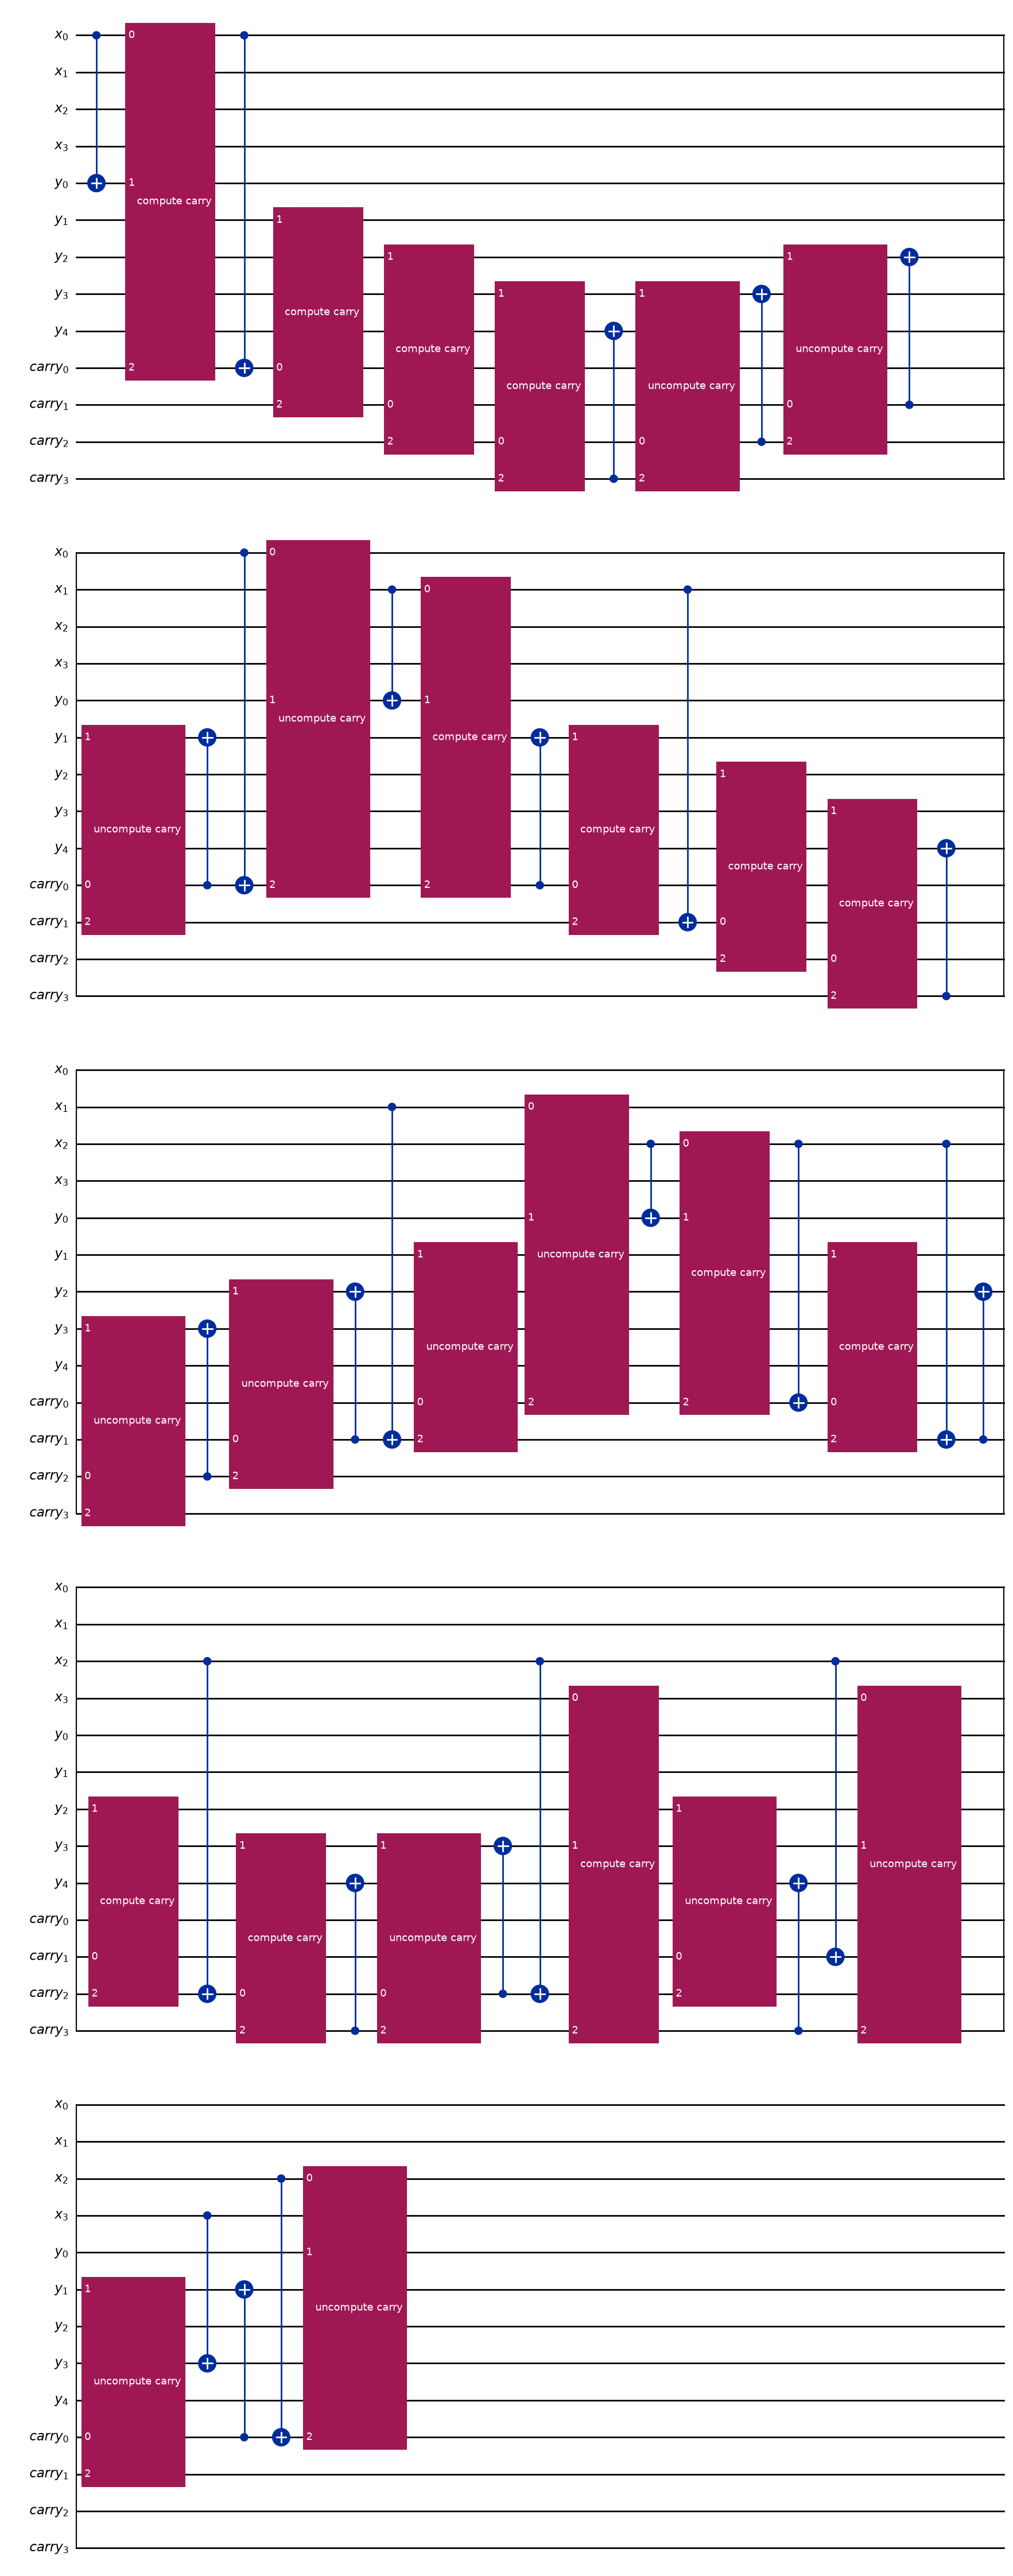

In [9]:
adder_circuit = QuantumCircuit(quantum_register, ancilla_register, carry_register, name="adder circuit")

for i in range(n):
    adder_circuit.compose(controlled_measurement_free_quantum_shifter(int(M[i]), int(bits_needed)), qubits=[quantum_register[i]] + ancilla_register[:] + carry_register[:], inplace=True)

Adder = adder_circuit.to_gate(label="adder")
adder_circuit.draw(output="mpl")

In [ ]:
#k = n,  
#d = the number that's maximal bits_needed to represent the maximum possible sum of subsets of M.
# Adder = controlled_measurement_free_quantum_shifter(k,d)
# Adder.draw(output="mpl")

In [11]:
Subtractor = Adder.inverse()

Here we need to turn our target t in to binary and store it in the ancilla register. We can do this by applying X gates to the ancilla qubits corresponding to the bits of t that are 1.

In [ ]:
quantum_register = QuantumRegister(size=n, name="x")
ancilla_register = AncillaRegister(size=d, name="y")

marker_circuit = QuantumCircuit(quantum_register, ancilla_register, name="marker")

### write the rest of the code below

marker_circuit.compose(Adder, inplace=True)



marker_circuit.x(ancilla_register[0])
marker_circuit.cz(ancilla_register[0], ancilla_register[1])
marker_circuit.x(ancilla_register[0])

marker_circuit.compose(Subtractor, inplace=True)

###

marker_circuit.draw(output="mpl")

# State Preparation

In [ ]:
state_preparation_circuit = QuantumCircuit(quantum_register, name="state preparation")
state_preparation_circuit.h(quantum_register)
state_preparation_circuit.draw(output="mpl")

In [ ]:
Prep = state_preparation_circuit.to_gate(label="Prep")

# Marker Circuit

# Diffuser Circuit


In [ ]:
diffuser_circuit = QuantumCircuit(quantum_register, name="diffuser")

diffuser_circuit.compose(Prep, inplace=True)

diffuser_circuit.x(quantum_register)

mcz_gate = ZGate().control(n-1)

diffuser_circuit.append(mcz_gate, quantum_register)

diffuser_circuit.x(quantum_register)

diffuser_circuit.compose(Prep.inverse(), inplace=True)

diffuser_circuit.draw(output="mpl")